# Palace CPW Simulation — Wave Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure with **wave ports**.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Define GSG electrode

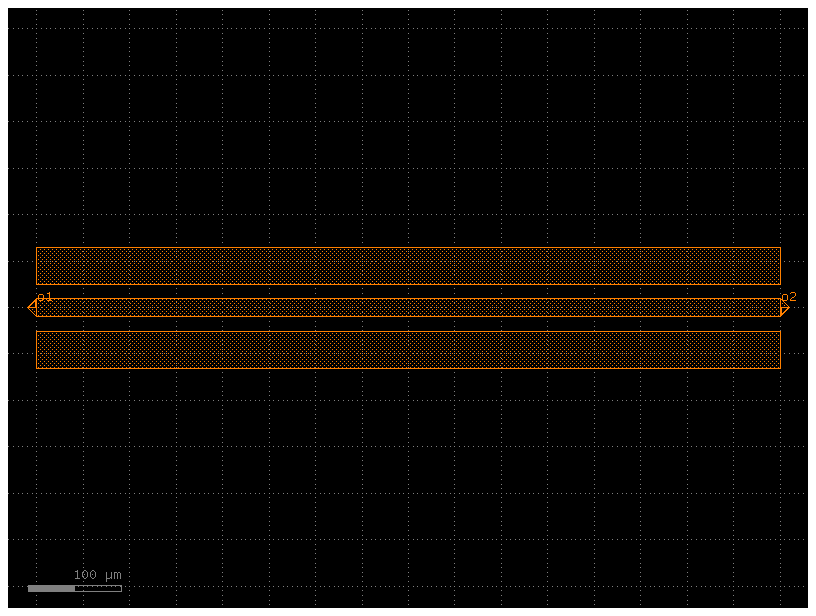

In [1]:
from pathlib import Path

import gdsfactory as gf
import gdsfactory.component as gf_component
import gdsfactory.config as gf_config
from ihp import LAYER, PDK

# Work around environments where /tmp/gdsfactory is not writable.
# Both modules keep their own reference to GDSDIR_TEMP, so update both.
gf_tmp = Path.home() / ".gdsfactory" / "tmp"
gf_tmp.mkdir(parents=True, exist_ok=True)
gf_config.GDSDIR_TEMP = gf_tmp
gf_component.GDSDIR_TEMP = gf_tmp

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure simulation

In [ ]:
from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-cpw-waveport")
sim.set_geometry(c)

stack = get_stack()  # auto-detects active PDK
sim.set_stack(stack)
sim.set_airbox(margin_x=0.0, margin_y=50, z_above=100.0, z_below=100.0)

# Wave ports — max_size fills the full domain boundary
sim.add_wave_port("o1", layer="topmetal2", max_size=True, mode=1, excited=True)
sim.add_wave_port("o2", layer="topmetal2", max_size=True, mode=1, excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

print(sim.validate_config())

### Generate mesh

In [ ]:
sim.mesh(preset="default", refined_mesh_size=2.0, max_mesh_size=40.0, fmax=150e9)

In [ ]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

### Run simulation

In [ ]:
import importlib

import gsim.common.cross_section as cross_section
from gsim.palace import BoundaryModeSim

palace_executable = "/home/martin/Desktop/palace/build/bin/palace"

# Reload in case cross_section.py changed during this session.
importlib.reload(cross_section)

# Build a BoundaryMode simulation on an x-normal cross section.
mode_sim = BoundaryModeSim()
mode_sim.set_output_dir("./palace-sim-cpw-waveport-2d")
mode_sim.set_geometry(c.copy())
mode_sim.set_stack(stack)
mode_sim.set_cross_section("x=0")
mode_sim.set_boundary_mode(freq=50e9, num_modes=2, save=2)

# Inspect the geometric cross section before meshing.
section = cross_section.extract_plane_section(c.copy(), stack, axis="x", value=0.0)
print(f"Cross section x=0 intersects {len(section)} layer regions")
print("Stack dielectric regions:", stack.dielectrics)

mode_sim.mesh(
    preset="default",
    refined_mesh_size=2.0,
    max_mesh_size=40.0,
    fmax=150e9,
    margin_x=0.0,
    margin_y=50.0,
)

# Show the native 2D domains used by the BoundaryMode solver.
domain_groups = list(mode_sim._last_mesh_result.groups["volumes"].keys())
print("2D domain groups:", domain_groups)
mode_sim.plot_mesh(show_groups=domain_groups, style="solid", interactive=True)

mode_sim.write_config()
mode_results = mode_sim.run_local(
    palace_executable=palace_executable,
    use_apptainer=False,
    num_processes=16,
    verbose=True,
)
mode_results

Cross section x=0 intersects 3 layer regions
Stack dielectric regions: [{'name': 'oxide', 'zmin': -2.0, 'zmax': 14.030000000000001, 'material': 'sio2'}, {'name': 'passive', 'zmin': 14.030000000000001, 'zmax': 15.930000000000001, 'material': 'sin'}]
2D domain groups: ['air', 'sin', 'sio2', 'topmetal2']



Widget(value='<iframe src="http://localhost:37055/index.html?ui=P_0x7d4a84192f30_0&reconnect=auto" class="pyvi…

### Plot S-parameters

In [3]:
results.plot_interactive()

Running Palace simulation in palace-sim-cpw-waveport-2d directly
Command: /home/martin/Desktop/palace/build/bin/palace -np 16 config.json
Processes: 16
>> /usr/bin/mpirun -n 16 /home/martin/Desktop/palace/build/bin/palace-x86_64.bin config.json
_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/
--> Warning!
Output folder is not empty; program will overwrite content! (output/palace)

---------- Registering Backends ----------

Backend Register: /cpu/self/avx/blocked
Backend Register: /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen
Weak Register   : /gpu/hip/shared
Weak Register   : /gpu/sycl/ref
Weak Register   : /gpu/sycl/shared
Weak Register   : /gpu/sycl/gen
Weak Register   : /gpu/cuda/magma
Weak Register

RuntimeError: Palace simulation failed with return code 1

Output (tail):
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen
Weak Register   : /gpu/hip/shared
Weak Register   : /gpu/sycl/ref
Weak Register   : /gpu/sycl/shared
Weak Register   : /gpu/sycl/gen
Weak Register   : /gpu/cuda/magma
Weak Register   : /gpu/hip/magma
Weak Register   : /gpu/cuda/magma/det
Weak Register   : /gpu/hip/magma/det
Weak Register   : /cpu/self/memcheck/blocked
Weak Register   : /cpu/self/memcheck/serial
Weak Register   : /cpu/self/occa
Weak Register   : /cpu/openmp/occa
Weak Register   : /gpu/dpcpp/occa
Weak Register   : /gpu/opencl/occa
Weak Register   : /gpu/hip/occa
Weak Register   : /gpu/cuda/occa
Backend Register: /cpu/self/opt/blocked
Weak Register   : /cpu/self/memcheck/serial
Weak Register   : /cpu/self/occa
Weak Register   : /cpu/openmp/occa
Weak Register   : /gpu/dpcpp/occa
Weak Register

In [ ]:
results.plot_interactive(phase=True)